# Data Science Assign 5: Online Shoppers Purchasing Intention Dataset

## Step 1: Imports & Config

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [7]:
pd.set_option("display.max_columns", 100)
DATA_PATH = "online_shoppers_intention.csv"

## Step 2: Load, Inspect, and Clean Dataset

In [8]:

df = pd.read_csv(DATA_PATH)

print("=== Head ===")
print(df.head())

print("\n=== Info ===")
print(df.info())

print("\n=== Describe (numeric) ===")
print(df.describe())


=== Head ===
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0        

In [9]:
# Convert boolean-like columns to bool
bool_cols = ["Weekend", "Revenue"]
for col in bool_cols:
    if df[col].dtype == object:
        df[col] = df[col].map(
            {
                "TRUE": True,
                "FALSE": False,
                "True": True,
                "False": False,
            }
        )

print("\n=== Check boolean columns ===")
print(df[bool_cols].head())

# Missing values
print("\n=== Missing values ===")
print(df.isna().sum())

# Feature lists
numeric_features = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]

categorical_features = [
    "Month", "OperatingSystems", "Browser", "Region",
    "TrafficType", "VisitorType", "Weekend"
]

target_col = "Revenue"

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target:", target_col)


=== Check boolean columns ===
   Weekend  Revenue
0    False    False
1    False    False
2    False    False
3    False    False
4     True    False

=== Missing values ===
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Numeric features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Categorical features: ['Month', 'OperatingSystems', 'Browser', 'Region', 'Traffic

## Step 3: Exploratory Data Analysis (EDA)

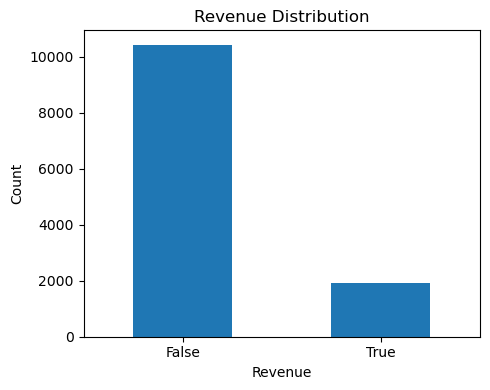


=== Revenue value counts (normalized) ===
Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


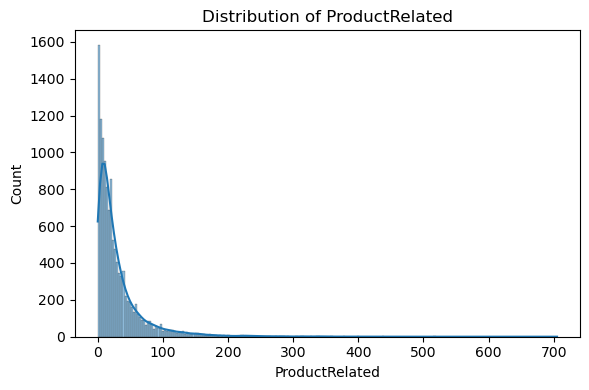

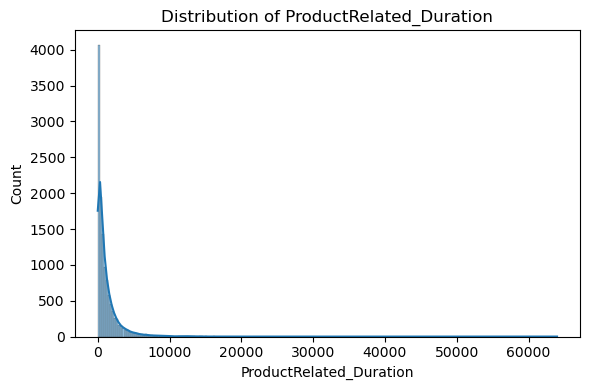

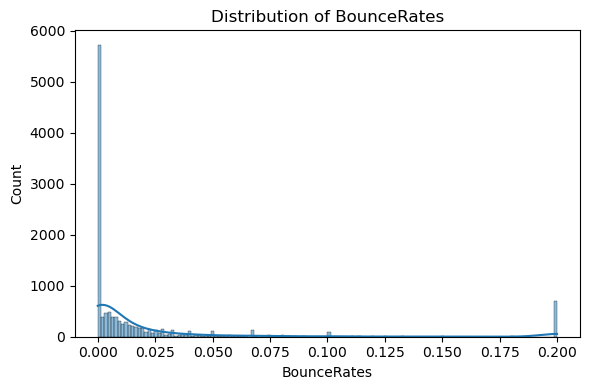

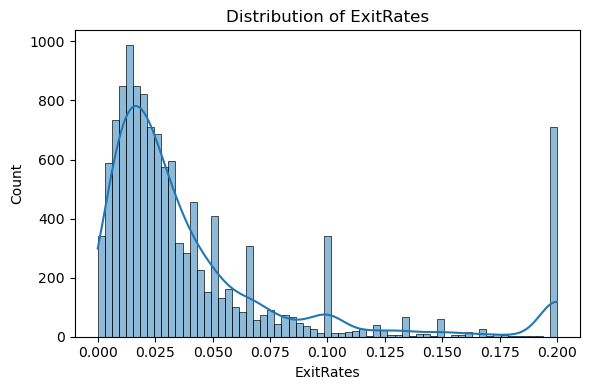

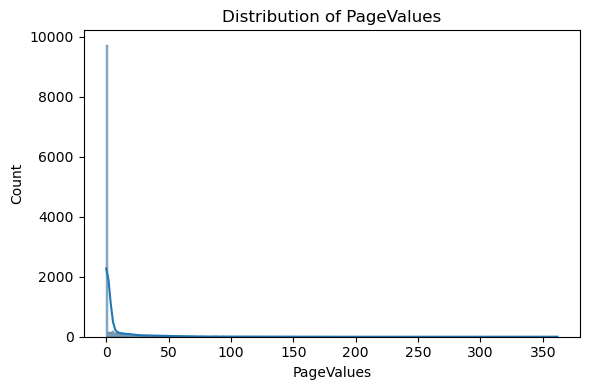

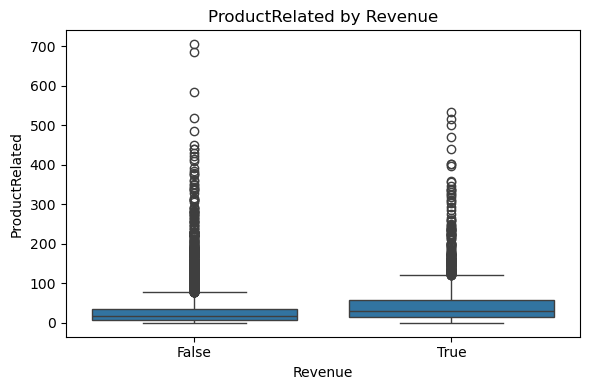

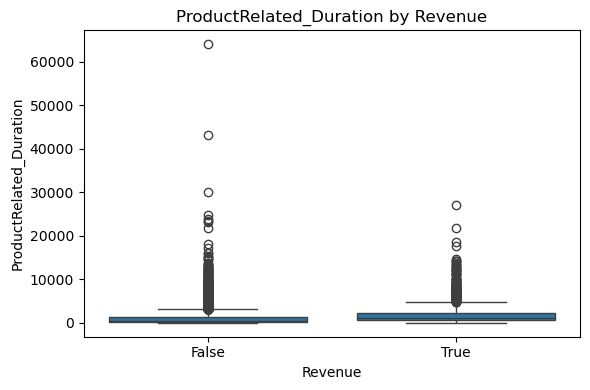

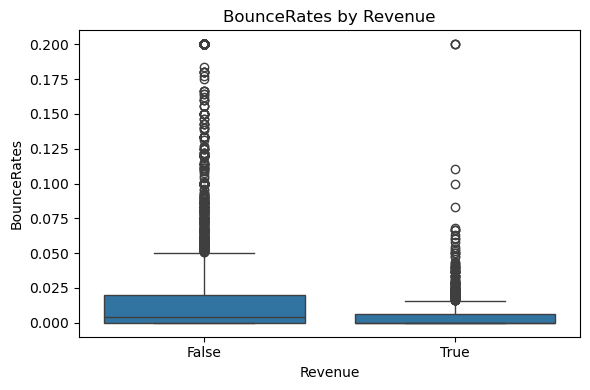

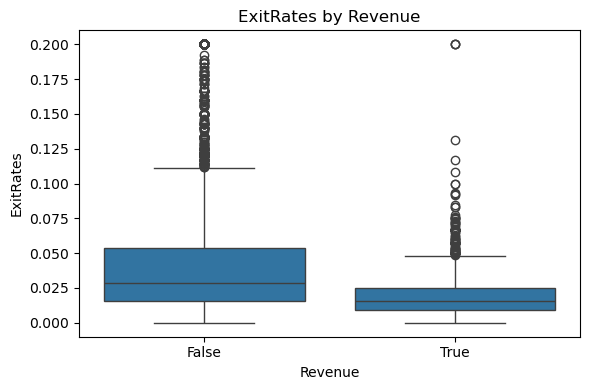

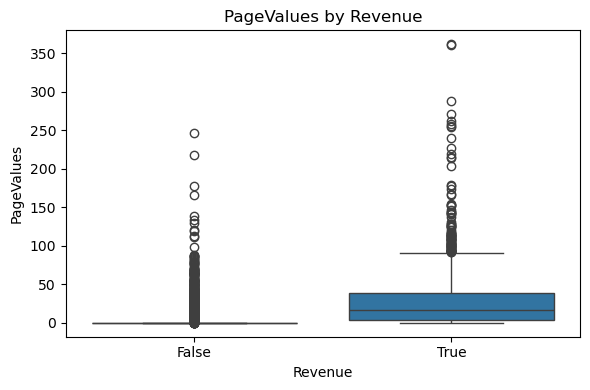

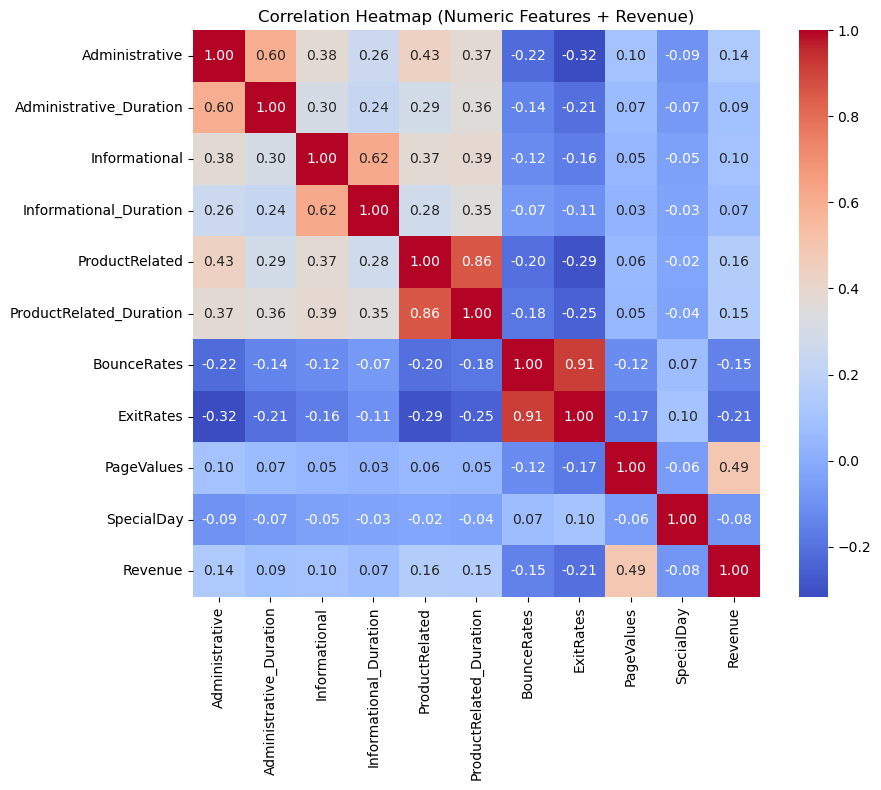

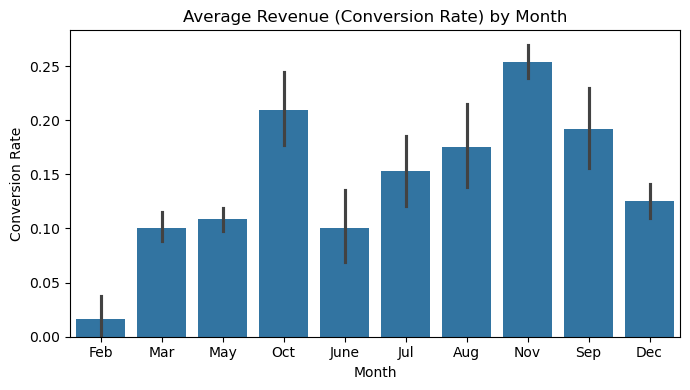

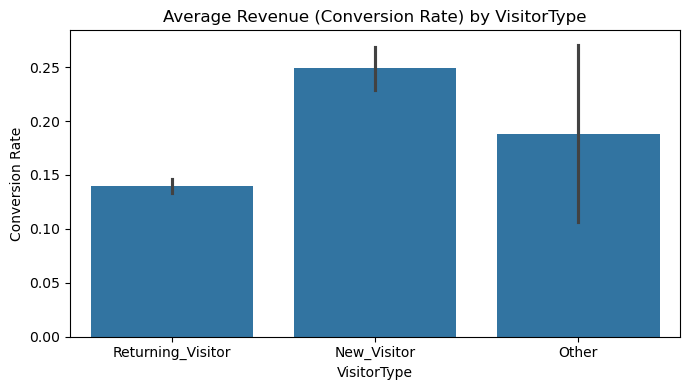

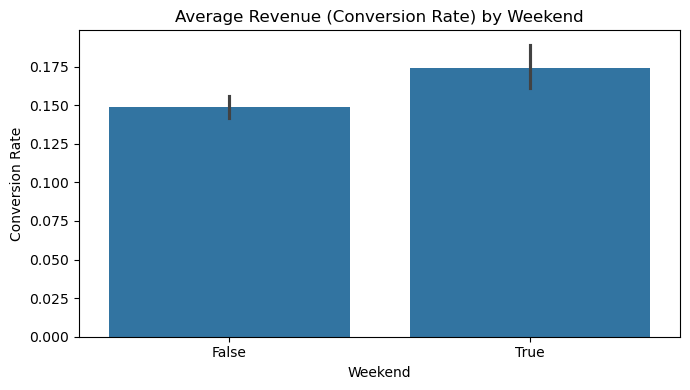


=== Duration columns 99th percentiles (for reference) ===
Administrative_Duration 830.5870409259969
Informational_Duration 716.3899999999921
ProductRelated_Duration 8701.142696919998


In [10]:
# 3.1 Target distribution
plt.figure(figsize=(5, 4))
df[target_col].value_counts().plot(kind="bar")
plt.title("Revenue Distribution")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("\n=== Revenue value counts (normalized) ===")
print(df[target_col].value_counts(normalize=True))

# 3.2 Histograms of selected numeric features
selected_numeric_for_plots = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

for col in selected_numeric_for_plots:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

# 3.3 Boxplots by target
for col in selected_numeric_for_plots:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=target_col, y=col)
    plt.title(f"{col} by Revenue")
    plt.tight_layout()
    plt.show()

# 3.4 Correlation heatmap (numeric + target)
corr_df = df[numeric_features + [target_col]].copy()
corr_df[target_col] = corr_df[target_col].astype(int)

corr_matrix = corr_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", square=True)
plt.title("Correlation Heatmap (Numeric Features + Revenue)")
plt.tight_layout()
plt.show()

# 3.5 Categorical vs Revenue (conversion rate)
cat_for_plot = ["Month", "VisitorType", "Weekend"]
for col in cat_for_plot:
    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=df,
        x=col,
        y=df[target_col].astype(int),
        estimator=np.mean
    )
    plt.title(f"Average Revenue (Conversion Rate) by {col}")
    plt.ylabel("Conversion Rate")
    plt.tight_layout()
    plt.show()

# 3.6 Outlier handling example for duration columns (clipping)
df_clipped = df.copy()
duration_cols = ["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration"]
for col in duration_cols:
    upper = df_clipped[col].quantile(0.99)
    df_clipped[col] = np.where(df_clipped[col] > upper, upper, df_clipped[col])

print("\n=== Duration columns 99th percentiles (for reference) ===")
for col in duration_cols:
    print(col, df[col].quantile(0.99))

## Step 4: Predictive Modeling

In [11]:
# Goal: predict Revenue (binary classification) from numeric + categorical features

X = df_clipped[numeric_features + categorical_features].copy()
y = df_clipped[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\n=== Train/Test shapes ===")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Preprocessing: one-hot encode categoricals, passthrough numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

# Logistic Regression pipeline
logreg_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

# Random Forest pipeline
rf_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=None,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

# Train
print("\n=== Training Logistic Regression ===")
logreg_clf.fit(X_train, y_train)

print("\n=== Training Random Forest ===")
rf_clf.fit(X_train, y_train)

# Evaluation helper
def evaluate_model(model, X_test, y_test, name="Model"):
    print(f"\n=== {name} Evaluation ===")
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix:")
    print(cm)

    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))


# Evaluate both models
evaluate_model(logreg_clf, X_test, y_test, name="Logistic Regression")
evaluate_model(rf_clf, X_test, y_test, name="Random Forest")

print("\n=== Done ===")


=== Train/Test shapes ===
X_train: (9247, 17)
X_test: (3083, 17)
y_train: (9247,)
y_test: (3083,)

=== Training Logistic Regression ===


/Users/jimmy928/miniconda3/envs/consumer-credit-analysis/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Training Random Forest ===

=== Logistic Regression Evaluation ===
Confusion matrix:
[[2317  289]
 [ 124  353]]
Precision: 0.550
Recall:    0.740

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2606
           1       0.55      0.74      0.63       477

    accuracy                           0.87      3083
   macro avg       0.75      0.81      0.77      3083
weighted avg       0.89      0.87      0.87      3083


=== Random Forest Evaluation ===
Confusion matrix:
[[2544   62]
 [ 256  221]]
Precision: 0.781
Recall:    0.463

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      2606
           1       0.78      0.46      0.58       477

    accuracy                           0.90      3083
   macro avg       0.84      0.72      0.76      3083
weighted avg       0.89      0.90      0.89      3083


=== Done ===
